# Вторая лабораторная работа

## Установка и импорт необходимых библиотек

In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-11.3.0-cp310-cp310-win_amd64.whl.metadata (9.2 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -------------- ------------------------- 2.9/8.1 MB 9.9 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 20.1 MB/s  0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   -------------- ------------------------- 3.1/8.9 MB 16.9 MB/s eta 0:00:01
   ----------------------------------- ---- 7.9/8.9 MB 18.1 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 16.7 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ----------------------------------

In [4]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set()

## Загрузка набора данных

In [5]:
df = pd.read_csv('archive/2cars_moldova.csv', delimiter = ',')
df

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro)
0,Toyota,Prius,2011,Hatchback,195000.0,1800.0,Hybrid,Automatic,7750.0
1,Renault,Grand Scenic,2014,Universal,135000.0,1500.0,Diesel,Manual,8550.0
2,Volkswagen,Golf,1998,Hatchback,1.0,1400.0,Petrol,Manual,2200.0
3,Renault,Laguna,2012,Universal,110000.0,1500.0,Diesel,Manual,6550.0
4,Opel,Astra,2006,Universal,200000.0,1600.0,Metan/Propan,Manual,4100.0
...,...,...,...,...,...,...,...,...,...
41002,Dacia,Logan Mcv,2015,Universal,89000.0,1500.0,Diesel,Manual,7000.0
41003,Renault,Modus,2009,Hatchback,225.0,1500.0,Diesel,Manual,4500.0
41004,Mercedes,E Class,2016,Sedan,50000.0,1950.0,Diesel,Automatic,29500.0
41005,Mazda,6,2006,Combi,370000.0,2000.0,Diesel,Manual,4000.0


## Разведывательный анализ данных

Просмотрим общую инфомрацию о наборе данных

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41007 entries, 0 to 41006
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Make                  41007 non-null  object 
 1   Model                 41007 non-null  object 
 2   Year                  41007 non-null  int64  
 3   Style                 41007 non-null  object 
 4   Distance              41007 non-null  float64
 5   Engine_capacity(cm3)  41007 non-null  float64
 6   Fuel_type             41007 non-null  object 
 7   Transmission          41007 non-null  object 
 8   Price(euro)           41007 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 2.8+ MB


In [7]:
df.describe()

,Year,Distance,Engine_capacity(cm3),Price(euro)
count,41007.000000,4.100700e+04,41007.000000,4.100700e+04
mean,2007.976175,4.567353e+05,1853.856732,9.727109e+03
std,8.241487,4.451897e+06,700.364532,5.043926e+04
min,1900.000000,0.000000e+00,0.000000,1.000000e+00
25%,2004.000000,8.750000e+04,1500.000000,3.500000e+03
50%,2009.000000,1.680000e+05,1800.000000,6.600000e+03
75%,2014.000000,2.300000e+05,2000.000000,1.215000e+04
max,2021.000000,1.000000e+08,9999.000000,1.000000e+07


Также можно отдельно вывести категориальные и численные признаки 

In [9]:
numeric_features = df.select_dtypes(include=[np.number])
category_features = df.select_dtypes(include=[object])

### Работа с численными признаками

И отобразить их с помощью гистограмм, доступных из библиотек seaborn и matplotlib

d:\GIT\MachineLearningUTMN\.venv\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


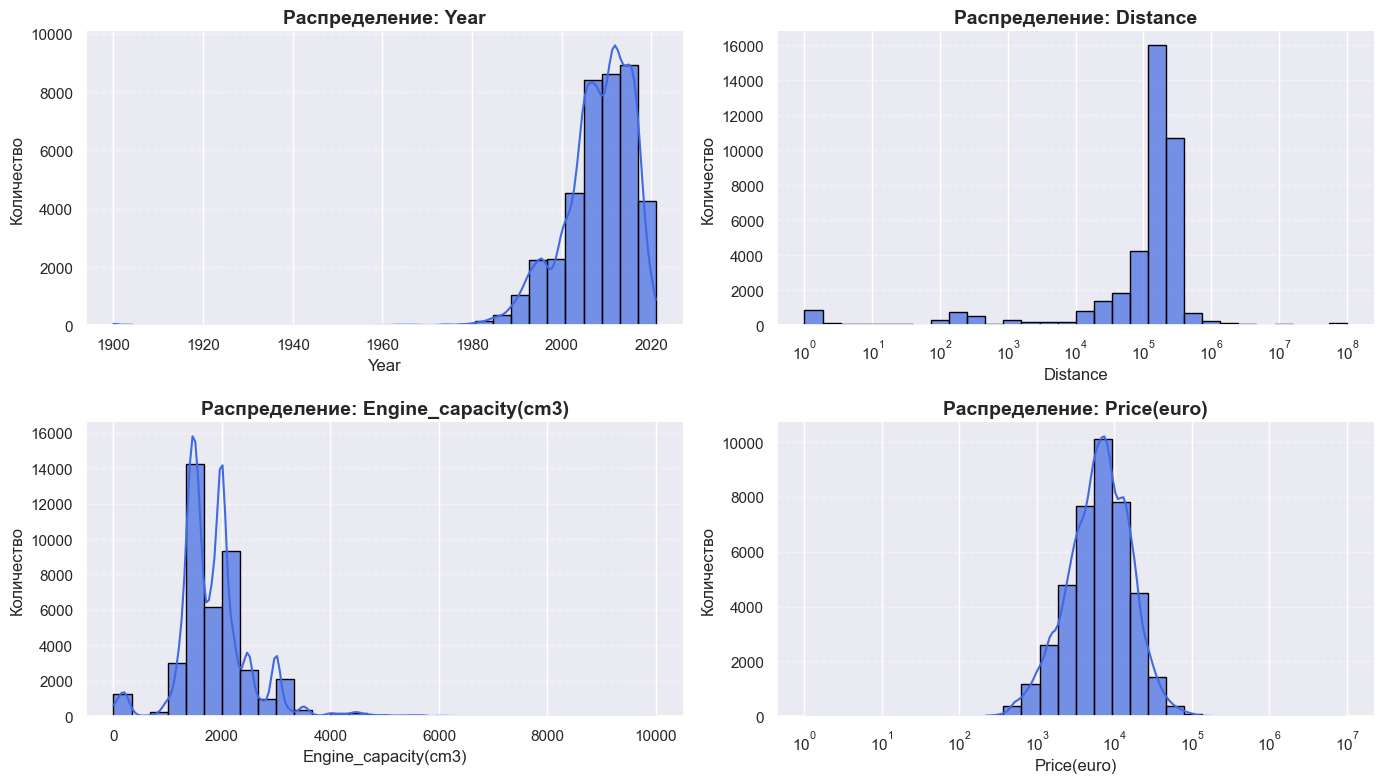

In [23]:
num_cols = len(numeric_features.columns)
fig, axes = plt.subplots(
    nrows=(num_cols + 1) // 2, ncols=2, figsize=(14, 4 * ((num_cols + 1) // 2))
)
axes = axes.flatten()

for i, column in enumerate(numeric_features.columns):
    if column in ['Price(euro)', 'Distance']:
        sns.histplot(df[column], bins=30, kde=True, color='royalblue', edgecolor='black', alpha=0.7, ax=axes[i], log_scale=True)
    else:
        sns.histplot(df[column], bins=30, kde=True, color='royalblue', edgecolor='black', alpha=0.7, ax=axes[i])
    axes[i].set_title(f'Распределение: {column}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel('Количество', fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()

На графиках можно наблюдать данные сильно отходящие от центра нормального распределения, возможно это связано с аномалиями и выбросами.

Чтобы избавиться от них, я отброшу все маловероятные данные

In [41]:
df_clean = df.copy()

for col in ['Distance', 'Price(euro)']:
    mu = df_clean[col].mean()
    sigma = df_clean[col].std()
    df_clean = df_clean[(df_clean[col] >= mu - 3 * sigma) & (df_clean[col] <= mu + 3 * sigma)]

df_clean = df_clean[df_clean['Year'] >= 1980]

df_clean = df_clean[df_clean['Engine_capacity(cm3)'] <= 5000]

df_clean = df_clean[df_clean['Price(euro)'] >= 100]
df_clean = df_clean[df_clean['Distance'] >= 10000]
df_clean = df_clean[df_clean['Distance'] <= 1000000]


И просмотрю новые графики

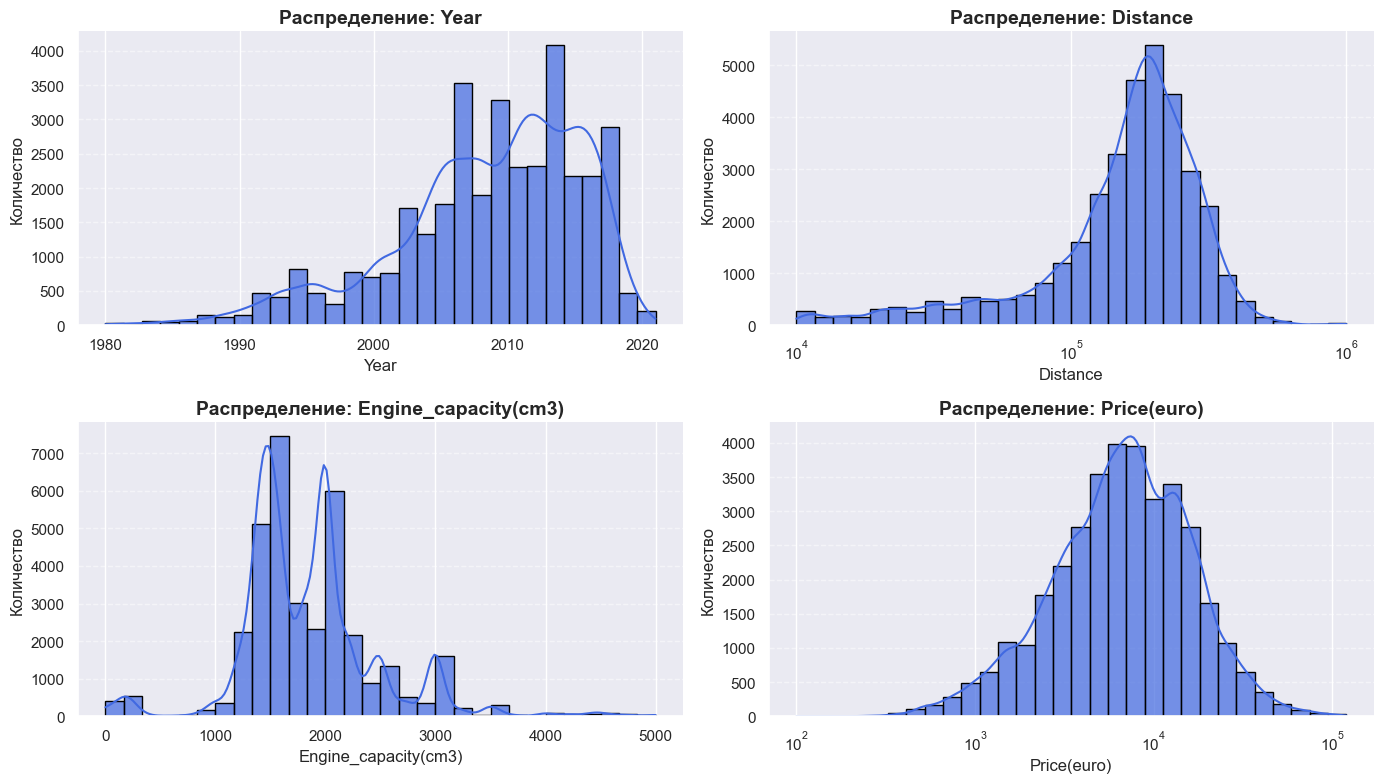

In [42]:
num_cols = len(numeric_features.columns)
fig, axes = plt.subplots(
    nrows=(num_cols + 1) // 2, ncols=2, figsize=(14, 4 * ((num_cols + 1) // 2))
)
axes = axes.flatten()

for i, column in enumerate(numeric_features.columns):
    if column in ['Price(euro)', 'Distance']:
        sns.histplot(df_clean[column], bins=30, kde=True, color='royalblue', edgecolor='black', alpha=0.7, ax=axes[i], log_scale=True)
    else:
        sns.histplot(df_clean[column], bins=30, kde=True, color='royalblue', edgecolor='black', alpha=0.7, ax=axes[i])
    axes[i].set_title(f'Распределение: {column}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(column, fontsize=12)
    axes[i].set_ylabel('Количество', fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()

Чтобы понимать, насколько важны будут признаки для задачи регрессии, можно посмотреть их корреляцию с целевым признаком

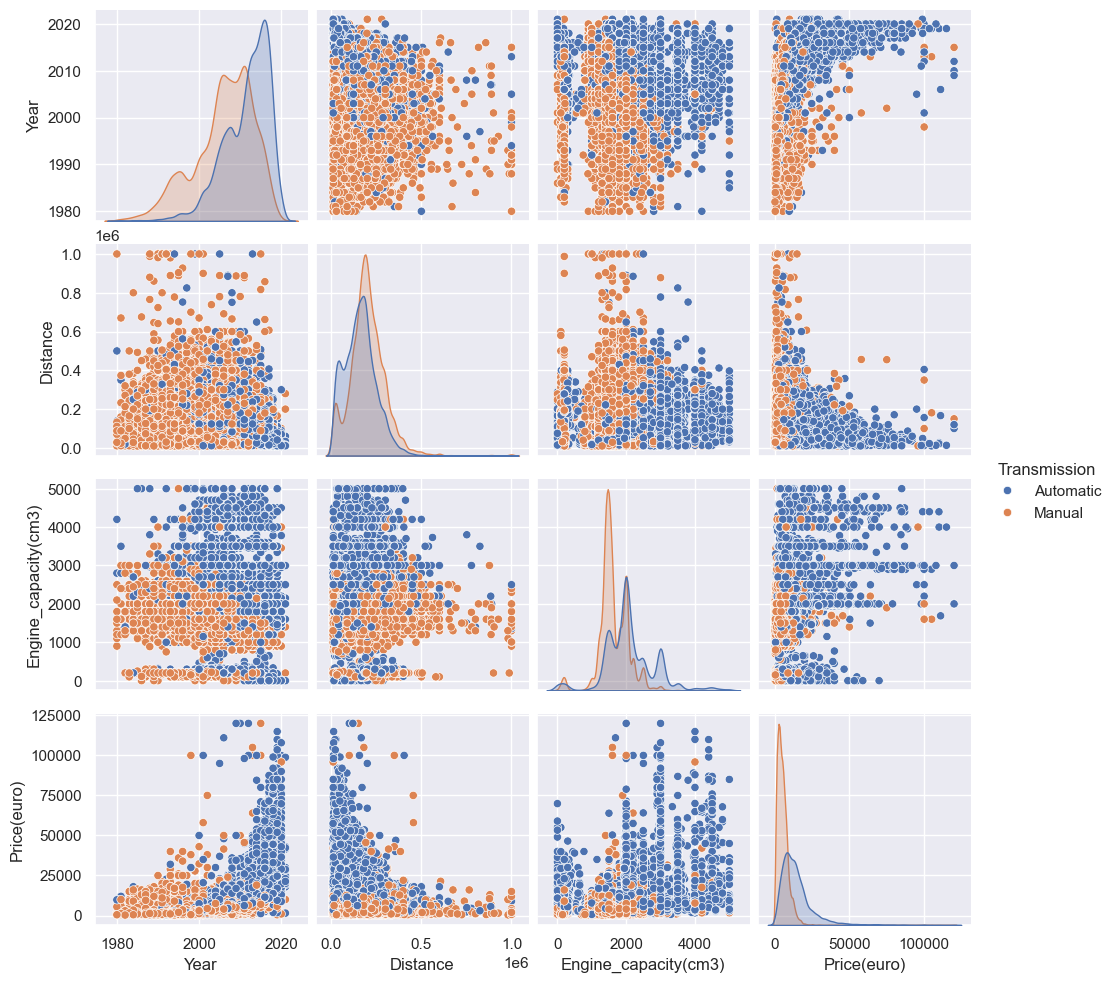

In [43]:
sns.pairplot(data = df_clean, hue ='Transmission');

#### Добавление колонки

Можно добавить новую колонку, которая бы имела более явную линейную корреляцию с целевым признаком

Например, пробег\год

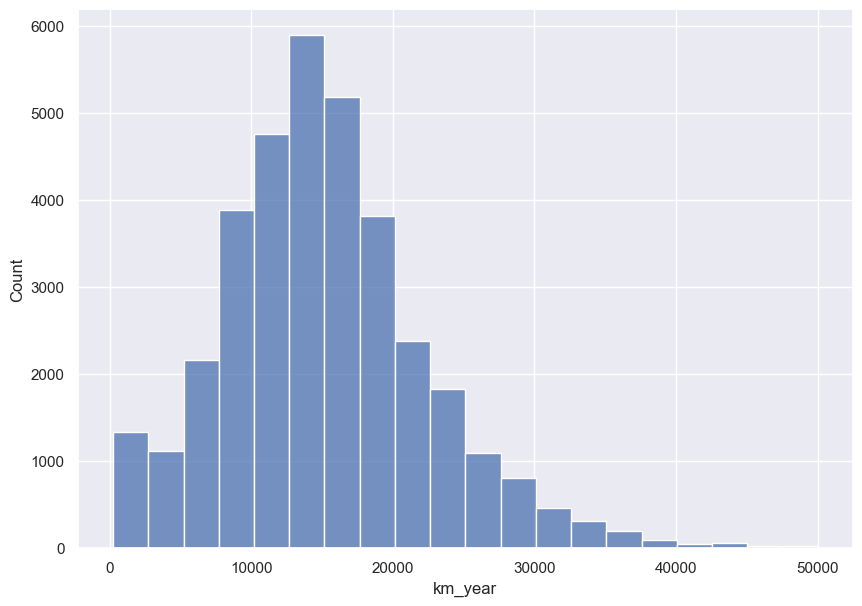

In [46]:
df_clean['km_year'] = df_clean.Distance / (2022 - df_clean.Year)
question_km_year = df_clean[df_clean.km_year > 50e3]
df_clean = df_clean.drop(question_km_year.index)
question_km_year = df_clean[df_clean.km_year < 100]
df_clean = df_clean.drop(question_km_year.index)
df_clean = df_clean.reset_index(drop=True)


plt.figure(figsize=(10,7))
sns.histplot(data=df_clean,
            x='km_year', bins = 20);

Проверим зависимость данного признака от других

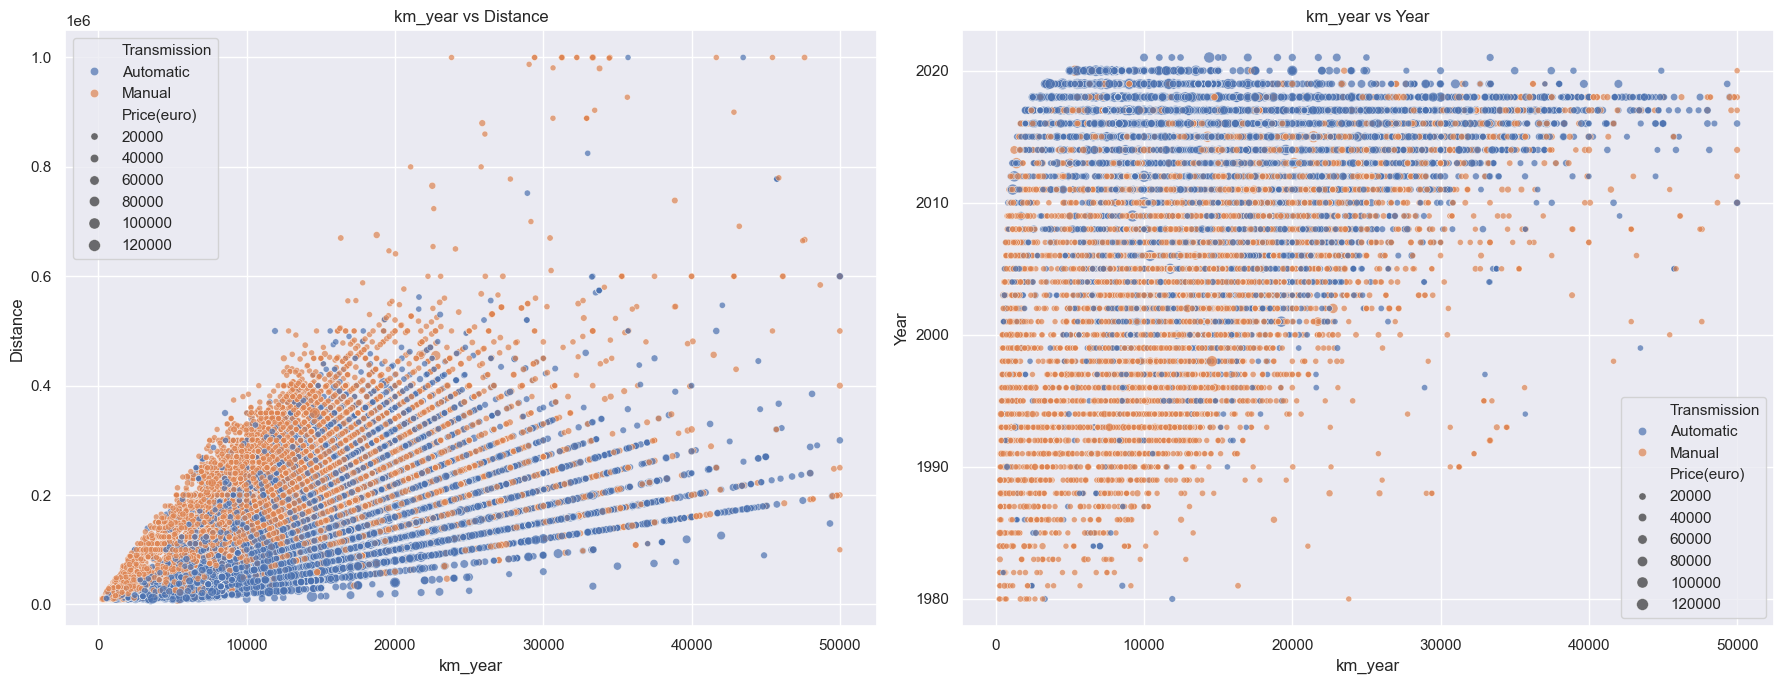

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    data=df_clean,
    x="km_year", y="Distance",
    hue="Transmission",
    size="Price(euro)", alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("km_year vs Distance")

sns.scatterplot(
    data=df_clean,
    x="km_year", y="Year",
    hue="Transmission",
    size="Price(euro)", alpha=0.7,
    ax=axes[1]
)
axes[1].set_title("km_year vs Year")

plt.tight_layout()
plt.show()

#### Дополнительное удаление аномалий

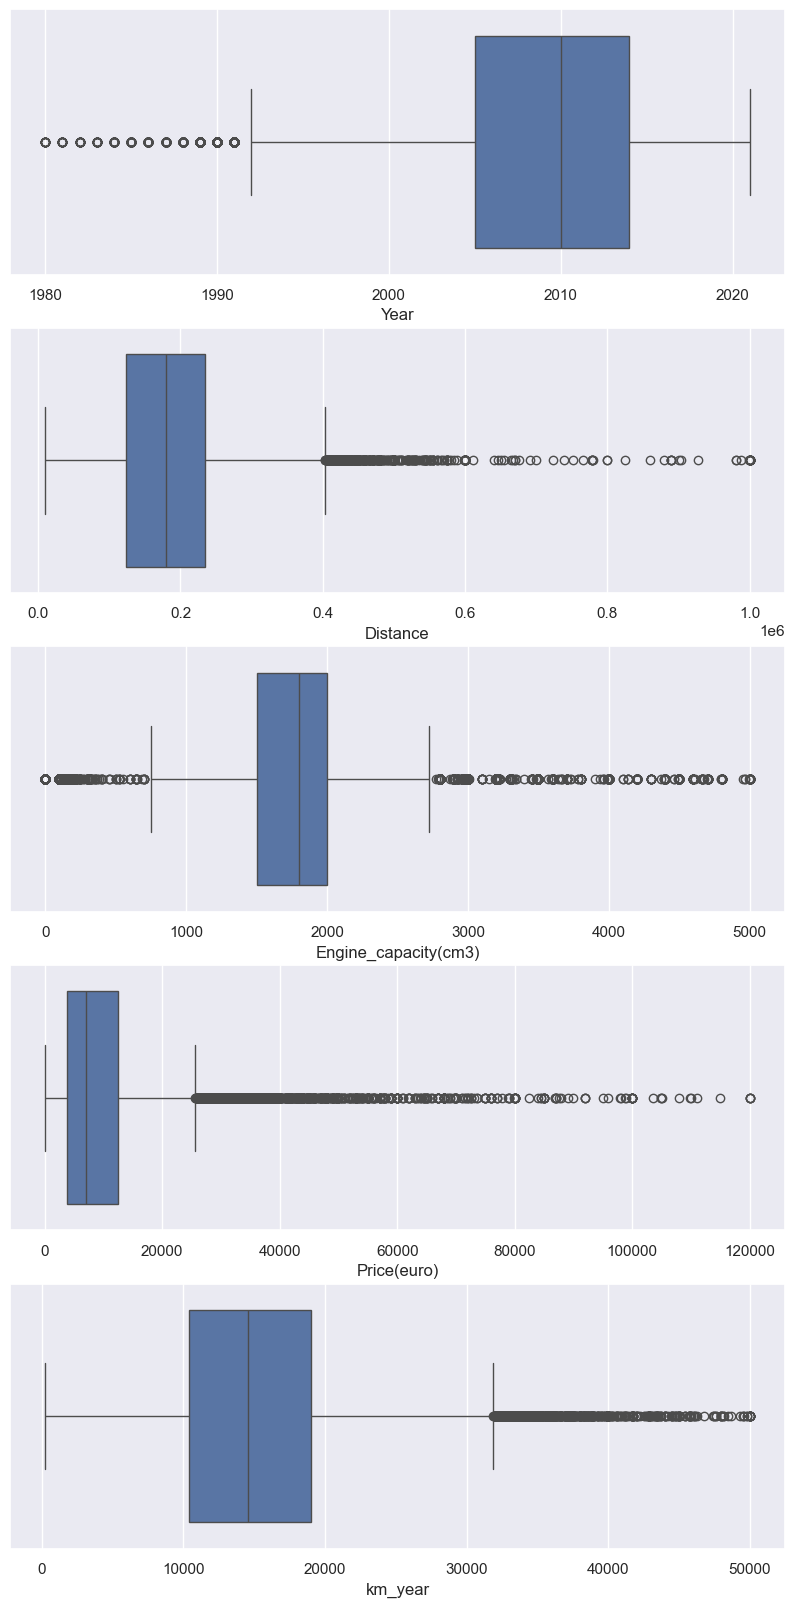

In [53]:
numeric_features = df_clean.select_dtypes(include=[np.number])

fig, ax = plt.subplots(nrows=5, ncols=1, figsize=(10,20))

for idx, column_name in enumerate(numeric_features):

    plt.subplot(5,1, idx+1)
    sns.boxplot(data=df_clean,
            x=column_name);

Посмотрим на корреляцию численных столбцов

In [65]:
correlation = numeric_features.corr()
correlation

,Year,Distance,Engine_capacity(cm3),Price(euro),km_year
Year,1.000000,-0.463465,-0.051730,0.548575,0.428727
Distance,-0.463465,1.000000,0.101398,-0.350054,0.440110
Engine_capacity(cm3),-0.051730,0.101398,1.000000,0.357493,0.011638
Price(euro),0.548575,-0.350054,0.357493,1.000000,0.174017
km_year,0.428727,0.440110,0.011638,0.174017,1.000000


In [66]:
correlation['Price(euro)']

Year                    0.548575
Distance               -0.350054
Engine_capacity(cm3)    0.357493
Price(euro)             1.000000
km_year                 0.174017
Name: Price(euro), dtype: float64

### Работа с категориальными признаками

Для начала пересчиатем строки с категориальными признаками, потому что меняли данные

In [75]:
category_features = df_clean.select_dtypes(include=[object])
category_features.nunique()

Make             78
Model           776
Style            12
Fuel_type         6
Transmission      2
dtype: int64

Посмотрим на число повторений в каждом категориальном признаке

In [82]:
counts = df_clean.Make.value_counts()
print(counts.median())

310.5


Редкие записи можно объединить под общим именем, напрмиер у меня это будут Other (другие)

In [78]:
other_make =  counts[(counts.values < 25)]
df_clean['Make'] = df_clean['Make'].replace(other_make.index.values, 'Other')
df_clean.Make.value_counts()

Make
Volkswagen    3718
Toyota        3390
Mercedes      3265
BMW           2783
Renault       2639
Opel          1961
Skoda         1893
Audi          1630
Nissan        1500
Ford          1488
Dacia         1454
Hyundai       1435
Honda          940
KIA            736
Mitsubishi     670
Lexus          648
Volvo          621
Mazda          471
Vaz            469
Chevrolet      431
Peugeot        417
Citroen        325
Land Rover     296
Other          274
Suzuki         264
Seat           257
Porsche        224
Fiat           206
Subaru         152
Rover           99
Chrysler        93
Smart           84
Jeep            78
Jaguar          74
Mini            74
Infiniti        73
Daewoo          66
Lincoln         54
Dodge           51
Alfa Romeo      35
Ssangyong       34
GAZ             30
Daihatsu        29
Tesla           25
Name: count, dtype: int64

Теперь также с моделями

In [89]:
counts = df_clean.Model.value_counts()
counts

Model
Other             6556
E Class           1201
5 Series          1103
Passat             915
Megane             879
                  ... 
GLC                 52
Accent              51
Grand Cherokee      51
Elantra             50
GL Class            49
Name: count, Length: 150, dtype: int64

In [90]:
print(counts.median())

110.5


In [85]:
counts[counts<100]

Model
Juke       97
Kuga       97
Combo      94
A Class    94
6          94
           ..
S-Coupe     1
Seltos      1
T-Cross     1
Delta       1
Siber       1
Name: count, Length: 725, dtype: int64

In [86]:
other_model =  counts[(counts.values < 50)]
df_clean['Model'] = df_clean['Model'].replace(other_model.index.values, 'Other')
df_clean.Model.value_counts()

Model
Other             6556
E Class           1201
5 Series          1103
Passat             915
Megane             879
                  ... 
GLC                 52
Accent              51
Grand Cherokee      51
Elantra             50
GL Class            49
Name: count, Length: 150, dtype: int64

## Приведение категориальных признаков к численным

Для трансмиссии, так как там всего два значения, можно сделать признак бинарным

In [91]:
df['Transmission'] = df['Transmission'].map({'Automatic': 1, 'Manual': 0})

Для остальных будем применять кодирование

In [ ]:
df_se = df.copy()
df_se[cat_columns] = df_se[cat_columns].astype('category')

for _, column_name in enumerate(cat_columns):
    df_se[column_name] =  df_se[column_name].cat.codes
df_se.info()

## Сохранение данных в файл

In [ ]:
df.to_csv('cars_moldova_clean.csv',index=False)